# **Instagram Reach Analysis**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Instagram.csv to Instagram.csv


**Import Libraries**

In [2]:
pip install wordcloud

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveRegressor

In [4]:
data = pd.read_csv('Instagram.csv', encoding='latin1')
data.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [5]:
data.isnull().sum()          # To check if there's and null value

,0
Impressions,0
From Home,0
From Hashtags,0
From Explore,0
From Other,0
Saves,0
Comments,0
Shares,0
Likes,0
Profile Visits,0


In [6]:
data = data.dropna()              # To drop any null value that exists

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [10]:
import warnings
warnings.filterwarnings('ignore')        # To ignore unnecessary warnings during visualizations

# **Visualizations**

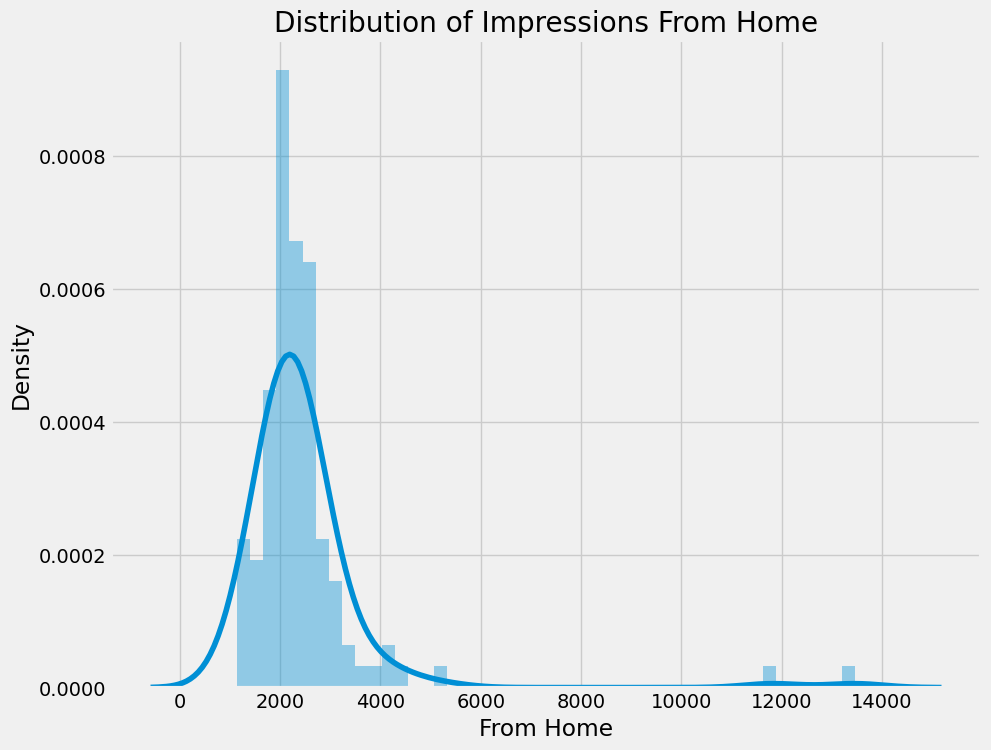

In [11]:
plt.figure(figsize=(10, 8))
plt.style.use('fivethirtyeight')
plt.title('Distribution of Impressions From Home')
sns.distplot(data['From Home'])
plt.show()

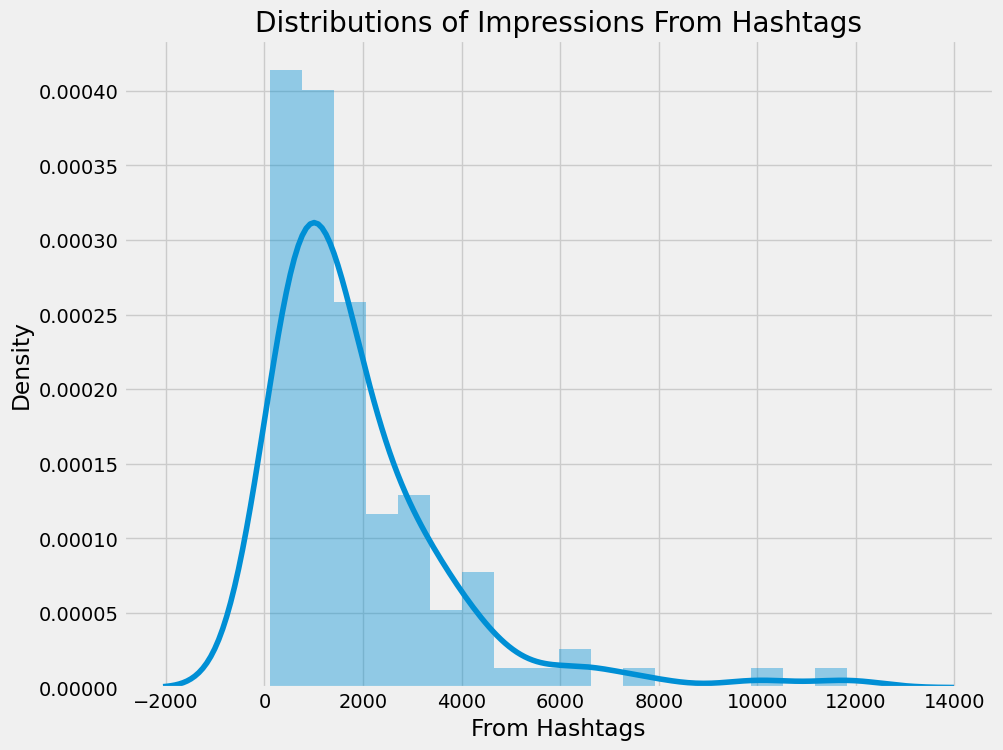

In [12]:
plt.figure(figsize=(10, 8))
plt.title('Distributions of Impressions From Hashtags')
sns.distplot(data['From Hashtags'])
plt.show()

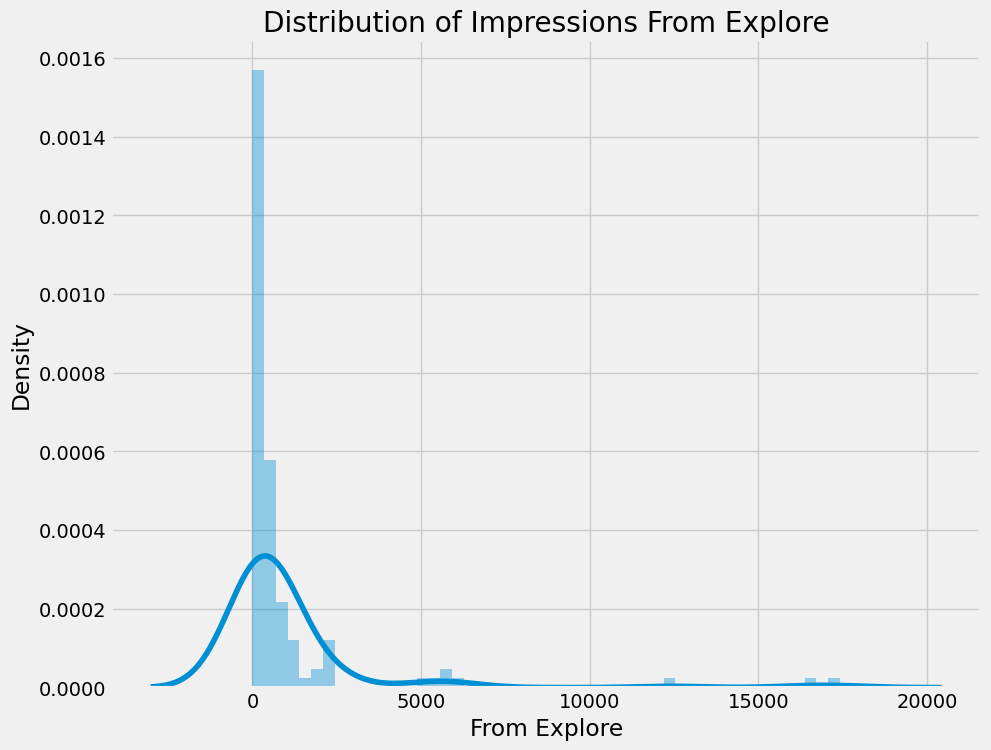

In [13]:
plt.figure(figsize=(10, 8))
plt.title('Distribution of Impressions From Explore')
sns.distplot(data['From Explore'])
plt.show()

In [14]:
home = data['From Home'].sum()
hashtags = data['From Hashtags'].sum()
explore = data['From Explore'].sum()
other = data['From Other'].sum()

labels = ['From Home','From Hashtags','From Explore','Other']
values = [home, hashtags, explore, other]

fig = px.pie(data,
             values=values,
             names=labels,
             title='Impressions on Instagram Posts From Various Sources',
             hole=0.5)
fig.show()

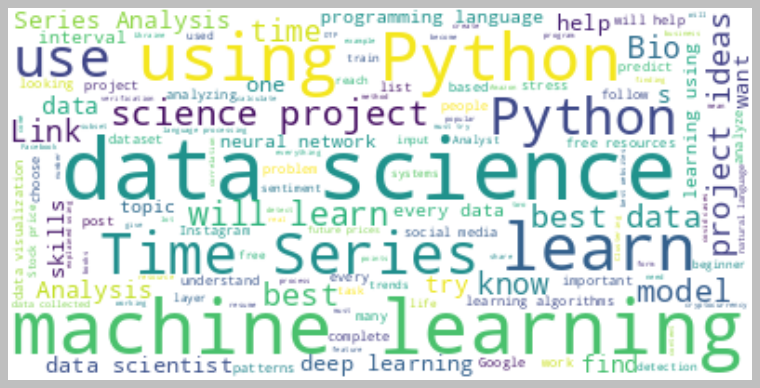

In [15]:
text = " ".join(i for i in data.Caption)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color='white').generate(text)
plt.style.use('classic')
plt.figure(figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

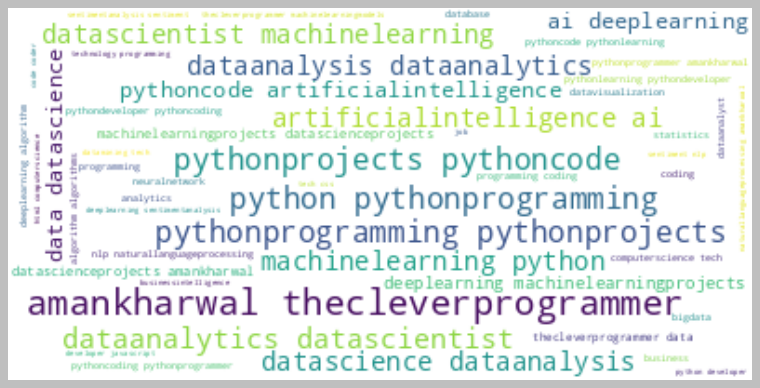

In [16]:
text = " ".join(i for i in data.Hashtags)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color='white').generate(text)
plt.style.use('classic')
plt.figure(figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# **Analyzing Relationships**

In [17]:
figure = px.scatter(data_frame=data,
                    x='Impressions',
                    y='Comments',
                    size='Comments',
                    trendline='ols',
                    title='Relationship Between Comments and Total Impressions'
                    )
figure.show()

In [18]:
figure = px.scatter(data_frame=data, x='Impressions',
                    y='Likes',
                    size='Likes',
                    trendline='ols',
                    title='Relationship Between Likes and Total Impressions')
figure.show()

In [19]:
figure = px.scatter(data_frame=data,
                    x='Impressions',
                    y='Shares',
                    size='Shares',
                    trendline='ols',
                    title='Relationship Between Shares and Total Impressions')
figure.show()

In [20]:
figure = px.scatter(data_frame=data,
                    x='Impressions',
                    y='Saves',
                    size='Saves',
                    trendline='ols',
                    title='Relationship Between Post Saves and Total Impressions'
                    )
figure.show()

**Correlation Analysis**

In [21]:
correlation = data.select_dtypes(include='number').corr()
print(correlation["Impressions"].sort_values(ascending=False))

Impressions       1.000000
From Explore      0.893607
Follows           0.889363
Likes             0.849835
From Home         0.844698
Saves             0.779231
Profile Visits    0.760981
Shares            0.634675
From Other        0.592960
From Hashtags     0.560760
Comments         -0.028524
Name: Impressions, dtype: float64


**Analyzing Conversion Rate**

In [39]:
conversion_rate = (data['Follows'].sum() / data['Profile Visits'].sum()) * 100    # Calculates profile visit to follower conversion rate
print(f'{conversion_rate:.2f}')           # Prints the percentage of people followed you after visiting your profile

41.00


In [23]:
figure = px.scatter(data_frame=data,
                    x='Profile Visits',
                    y='Follows',
                    size='Follows',
                    trendline='ols',
                    title='Relationship Between Profile Visits and Followers Gained')
figure.show()

# **Model Building**

In [24]:
x = np.array(data[['Likes','Saves','Comments','Shares','Profile Visits','Follows']])         # Indepenent Variables
y = np.array(data['Impressions'])                                                            # Target (Dependent) Variable
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [25]:
model = PassiveAggressiveRegressor()
model.fit(x_train, y_train)                          # Training the model on training data
model.score(x_test, y_test)                          # Evaluates model performance on test data (R² score)

0.7144658682691903

**Predictions**

In [34]:
# features = [['Likes','Saves','Comments','Shares','Profile Visits','Follows']]
features = np.array([[282.0, 233.0, 4.0, 9.0, 165.0, 54.0]])
prediction = model.predict(features)
print(f'Total Impressions: {prediction[0]:.2f}')

Total Impressions: 10857.65


# **Instagram Reach Analysis and Impressions Prediction using Machine Learning**

## **Objective**

The objective of this project is to analyze the performance of Instagram posts by exploring various engagement metrics and traffic sources, and to develop a machine learning model capable of predicting the **number of impressions** a post is likely to receive. The project combines **Exploratory Data Analysis (EDA)** with **Machine Learning** to better understand how user engagement influences the reach of Instagram posts.

---

## **Dataset**

The dataset contains information about Instagram posts along with several engagement-related metrics such as likes, comments, shares, saves, profile visits, follows, and impressions. These features help analyze user interaction and are later used to predict the total number of impressions generated by a post.

| Feature | Description |
|---------|-------------|
| Impressions | Total number of times a post was viewed |
| From Home | Impressions received from the Home feed |
| From Hashtags | Impressions generated through hashtags |
| From Explore | Impressions from the Explore page |
| From Other | Impressions from other Instagram sources |
| Saves | Number of users who saved the post |
| Comments | Number of comments received |
| Shares | Number of times the post was shared |
| Likes | Number of likes received |
| Profile Visits | Number of visits to the profile from the post |
| Follows | Number of new followers gained |
| Caption | Caption used for the Instagram post |
| Hashtags | Hashtags included in the post |

---

The required Python libraries were imported for data analysis, visualization, and machine learning. Various visualization techniques were then used to better understand the distribution of impressions from different Instagram traffic sources, including the Home feed, Hashtags, and the Explore page. These distribution plots help identify how impressions are spread across posts and whether most posts receive similar reach or if only a few posts generate exceptionally high impressions.

A pie chart was created to compare the contribution of different traffic sources, allowing an easy understanding of where the majority of Instagram impressions originate.

To analyze the textual content of the posts, **Word Clouds** were generated using both captions and hashtags. Frequently occurring words and hashtags appear larger in the visualization, providing insights into commonly used content and posting trends.

---

## **Exploratory Data Analysis (EDA)**

Scatter plots were created to study the relationship between **Impressions** and different engagement metrics, including **Likes**, **Comments**, **Shares**, and **Saves**. Each scatter plot includes a best-fit regression line, making it easier to observe whether higher engagement generally results in increased impressions.

A correlation matrix was also computed to measure the strength of the relationship between each numerical feature and the target variable (**Impressions**). Features with higher positive correlation values indicate a stronger influence on the overall reach of a post.

Additionally, the **Follower Conversion Rate** was calculated using the total number of profile visits and followers gained.

This metric measures the percentage of profile visitors who decided to follow the account, providing insight into how effectively profile visits are converted into new followers.

Another scatter plot was generated to analyze the relationship between **Profile Visits** and **Followers Gained**, helping visualize whether an increase in profile visits generally leads to acquiring more followers.

---

## **Model Building**

To build the prediction model, the following engagement metrics were selected as the input features:

- Likes
- Saves
- Comments
- Shares
- Profile Visits
- Follows

The target variable chosen for prediction was:

- **Impressions**

The dataset was divided into **80% training data** and **20% testing data** using `train_test_split()`, ensuring that the model could be evaluated on unseen data after training.

A **Passive Aggressive Regressor** was then trained using the training dataset. This regression algorithm learns the relationship between engagement metrics and impressions by continuously updating its model whenever prediction errors occur, making it suitable for numerical prediction tasks.

The model's performance was evaluated using the **R² Score**, which measures how well the model explains the variation in the target variable. We recieved the R² Score of `0.71` An R² value closer to **1** indicates better predictive performance.

---

## **Prediction**

After training, the model was used to predict the number of impressions for a new Instagram post using the following engagement values:

| Feature | Value |
|---------|------:|
| Likes | 282 |
| Saves | 233 |
| Comments | 4 |
| Shares | 9 |
| Profile Visits | 165 |
| Follows | 54 |

The trained Passive Aggressive Regression model analyzed these engagement metrics and estimated the expected number of impressions the post would receive. This demonstrates how machine learning can be used to forecast the potential reach of future Instagram posts based on user engagement.

---

## **Conclusion**

This project demonstrates a complete workflow for analyzing Instagram performance data and predicting post impressions using machine learning. The dataset was first explored through multiple visualizations, including distribution plots, pie charts, word clouds, scatter plots, and correlation analysis, providing valuable insights into engagement patterns and traffic sources. A Passive Aggressive Regression model was then trained using key engagement metrics to estimate the total impressions of new Instagram posts. The project illustrates how **Exploratory Data Analysis (EDA)** and **Machine Learning** can work together to better understand social media performance and support data-driven content strategies.